# EDA — ExoPredict Cloud

Análise exploratória do catálogo Kepler Objects of Interest (KOI), carregado na tabela `koi_raw` do banco `database/exopredict.db`.

Objetivo: entender a estrutura dos dados, o alvo (`koi_disposition`), qualidade (nulos/duplicados/outliers) e o comportamento das variáveis físicas por classe — para embasar a etapa de limpeza/transformação e a seleção de features sem vazamento de alvo (ver `data/README.md`).

## Setup

Carregamos os dados direto do SQLite (não do CSV) para reaproveitar a mesma fonte que o resto do pipeline usa (`src/load_to_database.py`, `src/inspect_database.py`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DATABASE_PATH = PROJECT_ROOT / "database" / "exopredict.db"

engine = create_engine(f"sqlite:///{DATABASE_PATH}")

df = pd.read_sql("SELECT * FROM koi_raw", engine)

sns.set_theme(style="whitegrid")
df.shape

(9564, 141)

## 1. Visão geral

Antes de entrar em distribuições, queremos saber: quantas colunas são medidas em si vs. metadados de incerteza (`_err1`/`_err2`), e quais os tipos de dado por coluna.

In [2]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

colunas_erro = [c for c in df.columns if c.endswith("_err1") or c.endswith("_err2")]
colunas_medida = [c for c in df.columns if c not in colunas_erro]

print(f"\nColunas de incerteza (_err1/_err2): {len(colunas_erro)}")
print(f"Demais colunas (medidas, flags, metadados): {len(colunas_medida)}")

df.dtypes.value_counts()

Linhas: 9564
Colunas: 141

Colunas de incerteza (_err1/_err2): 46
Demais colunas (medidas, flags, metadados): 95


float64    98
object     19
str        17
int64       7
Name: count, dtype: int64

## 2. Distribuição do alvo (`koi_disposition`)

Este é o problema mais importante para a etapa de modelagem: quão desbalanceadas estão as 3 classes? Isso decide se vamos precisar de técnicas de balanceamento (undersampling, oversampling, pesos de classe) mais na frente.

,quantidade,percentual
koi_disposition,,
FALSE POSITIVE,4839,50.6
CONFIRMED,2747,28.7
CANDIDATE,1978,20.7


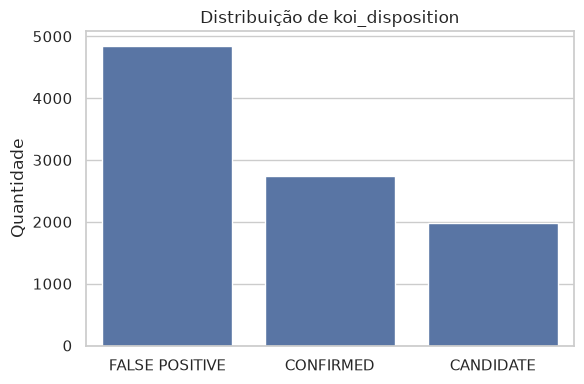

In [3]:
contagem = df["koi_disposition"].value_counts()
percentual = df["koi_disposition"].value_counts(normalize=True).mul(100).round(1)

resumo_alvo = pd.DataFrame({"quantidade": contagem, "percentual": percentual})
display(resumo_alvo)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="koi_disposition", order=contagem.index, ax=ax)
ax.set_title("Distribuição de koi_disposition")
ax.set_xlabel("")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

## 3. Valores ausentes

Objetivo: identificar quais colunas têm nulos, e o quão grave é isso (colunas 100% vazias já sabemos que existem, pela validação de qualidade — aqui queremos o espectro completo, não só o caso extremo).

Colunas com pelo menos um nulo: 120 de 141


Colunas 100% nulas: 19


,nulos,percentual
koi_ingress_err1,9564,100.0
koi_ingress_err2,9564,100.0
koi_ingress,9564,100.0
koi_longp_err2,9564,100.0
koi_longp,9564,100.0
koi_longp_err1,9564,100.0
koi_eccen_err1,9564,100.0
koi_eccen_err2,9564,100.0
koi_incl_err2,9564,100.0
koi_sma_err2,9564,100.0


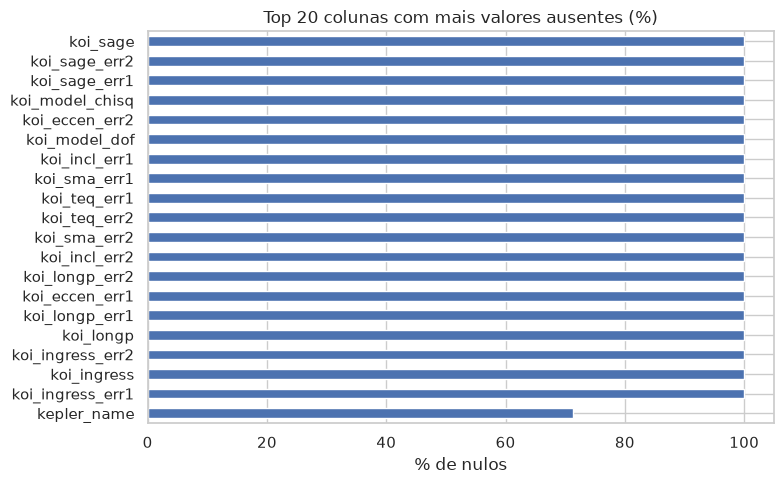

In [4]:
nulos = df.isna().sum()
percentual_nulos = (nulos / len(df) * 100).round(1)

resumo_nulos = (
    pd.DataFrame({"nulos": nulos, "percentual": percentual_nulos})
    .query("nulos > 0")
    .sort_values("percentual", ascending=False)
)

print(f"Colunas com pelo menos um nulo: {len(resumo_nulos)} de {df.shape[1]}")
print(f"Colunas 100% nulas: {(resumo_nulos['percentual'] == 100.0).sum()}")

display(resumo_nulos.head(20))

fig, ax = plt.subplots(figsize=(8, 5))
resumo_nulos.head(20)["percentual"].sort_values().plot.barh(ax=ax)
ax.set_title("Top 20 colunas com mais valores ausentes (%)")
ax.set_xlabel("% de nulos")
plt.tight_layout()
plt.show()

In [5]:
faixas = pd.cut(
    resumo_nulos["percentual"],
    bins=[0, 5, 20, 50, 80, 100],
    include_lowest=True,
)
display(faixas.value_counts().sort_index())

display(resumo_nulos.iloc[19:40])

percentual
(-0.001, 5.0]    70
(5.0, 20.0]      30
(20.0, 50.0]      0
(50.0, 80.0]      1
(80.0, 100.0]    19
Name: count, dtype: int64

,nulos,percentual
kepler_name,6817,71.3
koi_bin_oedp_sig,1510,15.8
koi_score,1510,15.8
koi_comment,1209,12.6
koi_max_sngle_ev,1142,11.9
koi_max_mult_ev,1142,11.9
koi_quarters,1142,11.9
koi_num_transits,1142,11.9
koi_fwm_stat_sig,1076,11.3
koi_fwm_prao_err,830,8.7


## 4. Duplicados

`kepoi_name` já é validado como chave única sem duplicados (`src/validate_data_quality.py`). Aqui investigamos duplicidade em outro nível: será que o mesmo sistema estelar (`kepid`) aparece mais de uma vez, e será que existem linhas com os mesmos parâmetros físicos (possível duplicidade de registro por erro de exportação)?

In [6]:
kepids_duplicados = df["kepid"].duplicated().sum()
print(f"kepid duplicado (mesma estrela, KOIs diferentes): {kepids_duplicados}")
print(f"Estrelas únicas (kepid): {df['kepid'].nunique()} para {len(df)} KOIs")

colunas_fisicas = ["koi_period", "koi_duration", "koi_depth", "koi_prad"]
linhas_duplicadas = df.duplicated(subset=colunas_fisicas, keep=False)
print(f"\nLinhas com mesmos {colunas_fisicas}: {linhas_duplicadas.sum()}")

kepid duplicado (mesma estrela, KOIs diferentes): 1350
Estrelas únicas (kepid): 8214 para 9564 KOIs

Linhas com mesmos ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad']: 0


## 5. Outliers nas variáveis físicas principais

Olhamos `koi_period` (período orbital), `koi_prad` (raio do planeta), `koi_depth` (profundidade do trânsito) e `koi_duration` (duração do trânsito).

Usamos escala logarítmica no eixo: grandezas astronômicas como essas costumam ter cauda longa (a maioria dos planetas é pequena/de período curto, mas existem gigantes e períodos longos que esticam a escala). Em escala linear, o boxplot ficaria ilegível — a caixa comprimida perto de zero e quase tudo marcado como outlier.

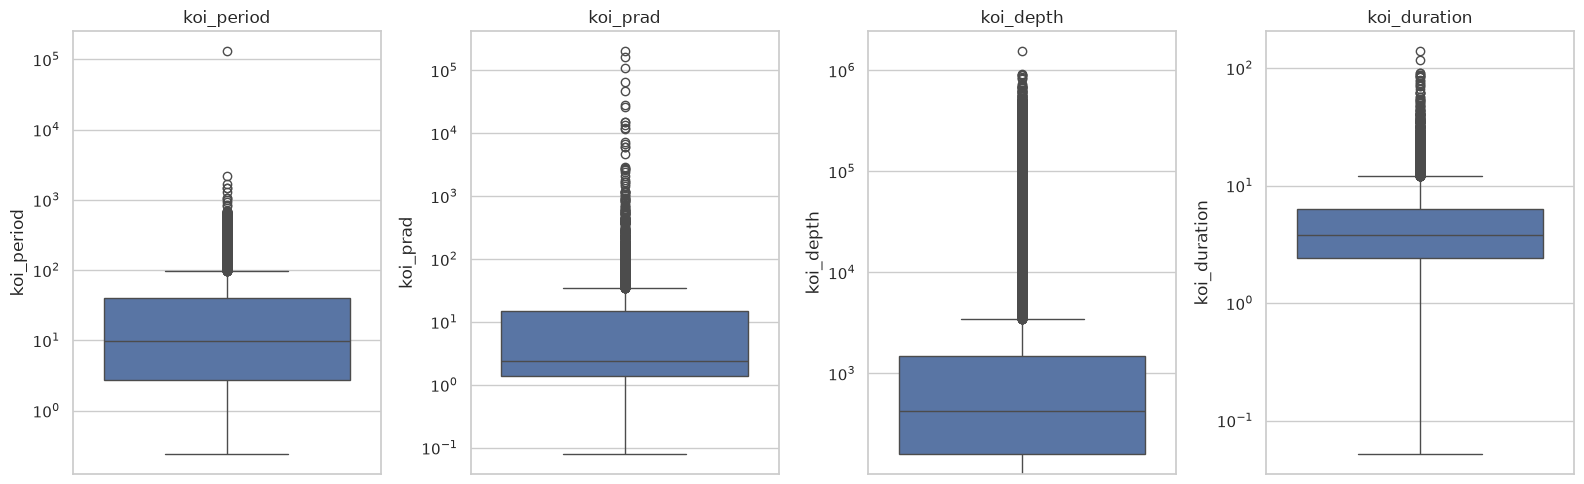

,q1,q3,limite_superior,outliers_iqr,percentual_outliers
koi_period,2.734,40.715,97.687,1567.0,16.4
koi_prad,1.400,14.930,35.225,1469.0,16.0
koi_depth,159.900,1473.400,3443.650,1798.0,19.5
koi_duration,2.438,6.276,12.035,869.0,9.1


In [7]:
colunas_fisicas = ["koi_period", "koi_prad", "koi_depth", "koi_duration"]

fig, axes = plt.subplots(1, len(colunas_fisicas), figsize=(16, 5))

for ax, coluna in zip(axes, colunas_fisicas):
    sns.boxplot(y=df[coluna], ax=ax)
    ax.set_yscale("log")
    ax.set_title(coluna)

plt.tight_layout()
plt.show()

def resumo_outliers_iqr(serie: pd.Series) -> dict:
    valida = serie.dropna()
    q1, q3 = valida.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = ((valida < limite_inferior) | (valida > limite_superior)).sum()
    return {
        "q1": round(q1, 3),
        "q3": round(q3, 3),
        "limite_superior": round(limite_superior, 3),
        "outliers_iqr": int(outliers),
        "percentual_outliers": round(outliers / len(valida) * 100, 1),
    }

resumo = pd.DataFrame({coluna: resumo_outliers_iqr(df[coluna]) for coluna in colunas_fisicas}).T
resumo

### koi_prad tem valores fisicamente plausíveis?

O boxplot mostra pontos próximos de 10⁵ raios terrestres — maior que o raio do Sol (~109 R⊕). Antes de tratar isso como "outlier estatístico normal", vale checar se são erros de medida/unidade ou extremos reais (ex: candidato claramente espúrio que o vetting já reprovou).

In [8]:
maiores_prad = df.nlargest(10, "koi_prad")[
    ["kepoi_name", "koi_disposition", "koi_prad", "koi_period", "koi_score"]
]
maiores_prad

,kepoi_name,koi_disposition,koi_prad,koi_period,koi_score
8893,K06604.01,FALSE POSITIVE,200346.0,410.885270,NaN
8747,K07251.01,FALSE POSITIVE,161858.0,581.072300,NaN
7151,K05873.01,CANDIDATE,109061.0,217.170081,NaN
8529,K06704.01,FALSE POSITIVE,64333.8,359.534371,NaN
6336,K05214.01,FALSE POSITIVE,46743.4,256.846143,NaN
6667,K05681.01,CANDIDATE,28199.3,77.512570,NaN
5533,K03800.01,FALSE POSITIVE,26042.9,1.247157,0.0
7278,K06200.01,FALSE POSITIVE,15056.9,200.762693,NaN
2361,K00267.01,FALSE POSITIVE,15049.8,165.755970,NaN
8479,K07231.02,CANDIDATE,13333.5,4.747015,NaN
